# 07 — Security Properties and Limitations

This scheme is a **reversible encryption scheme** providing semantic security for stored geographic coordinates. It is **not** a formal privacy primitive, not a differential privacy system, and not a substitute for k-anonymity.

This notebook provides an honest inventory of what the scheme does and does not protect, together with concrete directions for improvement.

<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Security analysis of the complete four-step pipeline</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:0;position:relative;z-index:4;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB02</div><div style="font-weight:700;font-size:13px;">① Project</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:3;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB03</div><div style="font-weight:700;font-size:13px;">② Snap+Shuffle</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:2;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB04</div><div style="font-weight:700;font-size:13px;">③ Lock</div></div>
    <div style="background:#2a9d8f;color:white;padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:1;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB05</div><div style="font-weight:700;font-size:13px;">④ Wobble</div></div>
</div>
</div>

## Learning Objectives

By the end of this notebook you will be able to:

1. **Name** the five documented limitations of the map encryption scheme.
2. **Summarize** the threat model by identifying adversary types, their capabilities, and the information they can observe.
3. **Differentiate** between the confidentiality guarantees the scheme provides and the formal anonymity guarantees it does not.
4. **Assess** the operational consequences of catastrophic key compromise and whether key rotation fully mitigates the risk.
5. **Propose** one concrete technical improvement — with a justification grounded in the threat model — that would address a specific documented limitation.

In [1]:
import secrets
import math
import numpy as np

from map_encryption import (
    MapEncryption, SchemeParams, SCHEME_VERSION,
    _project, _unproject, _R_EARTH,
)

CENTER_LAT, CENTER_LON = 51.513341, -0.136668  # Broadwick Street pump, Soho, London (1854 cholera outbreak)

## Security Property Inventory

The module docstring lists six security properties. Here is what each prevents:

| # | Property | Mechanism | What it prevents |
|---|----------|-----------|------------------|
| 1 | Unbiased PRP via rejection sampling | BLAKE2s with discard loop | Frequency-fingerprint attack on encrypted tile distribution |
| 2 | Length-prefixed Associated Data | `struct.pack('>iiI', qx, qy, len(tweak))` | Boundary-shift: two distinct ADs cannot produce identical bytes |
| 3 | Per-record jitter from nonce | `BLAKE2s(jitter_key, pack(qxp,qyp) + nonce)` | Co-location fingerprinting: same tile, different display pin |
| 4 | Record-ID binding via tweak | `make_tweak(record_id, extra)` | Record-substitution: ciphertext cannot be re-used for another record |
| 5 | Single master key with HKDF-style KDF | BLAKE2s with label + version | Cross-primitive key reuse enabling chosen-plaintext cross-key attacks |
| 6 | Scheme version field | `version = SCHEME_VERSION` in every record | Silent cross-version decryption after key rotation |

## Threat Model

| Principal | Can observe | Cannot observe | Scheme guarantee |
|-----------|-------------|----------------|-----------------|
| Database reader (no key) | qxp, qyp, nonce, ct_resid, tweak, version (all fields) | Original tile (qx, qy), residual (rx, ry), exact location | IND-CPA: records are computationally indistinguishable from random |
| Network observer | Record structure in transit | Plaintext if TLS in use; key material never in transit | AEAD integrity: tampering is detected; no location leaks via metadata |
| Display-tier operator (`jitter_key` only) | Approximate display position (±62.5 m of shuffled tile) | Exact GPS coordinates; tile identity; record linkage | Display tier needs only `jitter_key`; blast radius limited |
| Decode-tier operator (`prp_key` + `aead_key`) | Exact (lat, lon) of any record | Cannot derive master key from subkeys (one-way KDF) | Full precision recovery; integrity verification on every decode |
| Key holder (master key) | All subkeys; can decrypt anything | N/A — full access | KMS/HSM custody recommended; audit log all key uses |

## Limitation 1 — No Formal Anonymity

This scheme does **not** provide differential privacy or k-anonymity. The encrypted tile indices `(qxp, qyp)` are deterministic for a given tile and key — an attacker who can issue repeated bounding-box queries against `(qxp, qyp)` and observe which records fall within the box may infer statistical areas of interest across millions of records.

For formal location privacy, consider **geo-indistinguishability** (Andres et al., 2013), which adds calibrated Laplace noise to satisfy a differential-privacy guarantee for geographic data.

## Limitation 2 — Access-Pattern Leakage

Encrypting coordinates does **not** hide:
- Which records are fetched from the database
- Query frequency and timing patterns
- Temporal correlations (e.g., a record fetched repeatedly at commute times)

An attacker with database query logs can perform traffic analysis. Mitigations include Oblivious RAM (ORAM) for access-pattern hiding, query-rate limiting, and differential privacy on aggregate query counts.

## Limitation 3 — Web Mercator Distortion

A 250 m Mercator tile covers `250 / cos(lat)` metres of real ground. At 60°N (Oslo, Stockholm, Helsinki), the effective tile size is approximately 500 m — twice the stated bin size. At 80°N (northern Svalbard), a tile spans about 1440 m.

For polar deployments, replace Web Mercator with a local **UTM zone** or **national grid** (e.g., ETRS89-NTM for Norway) which provides near-equal-area tiling in the region of interest.

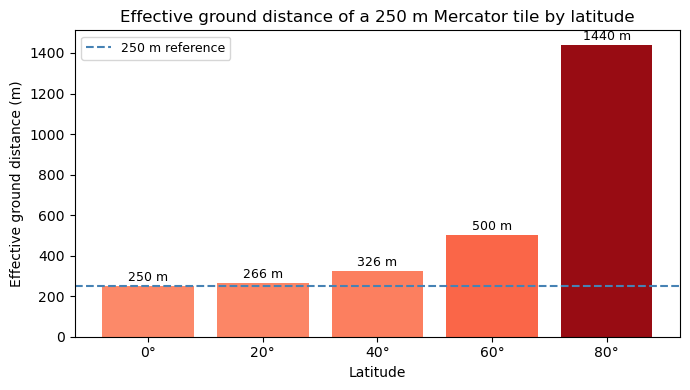

In [2]:
import matplotlib.pyplot as plt

lat_samples = [0, 20, 40, 60, 80]
effective_m = [250 / math.cos(math.radians(lat)) for lat in lat_samples]
labels = [f'{lat}°' for lat in lat_samples]

fig, ax = plt.subplots(figsize=(7, 4))
colors = plt.cm.Reds([0.3 + 0.6 * v / max(effective_m) for v in effective_m])
bars = ax.bar(labels, effective_m, color=colors)
ax.axhline(250, color='steelblue', linestyle='--', label='250 m reference')
ax.set_xlabel('Latitude')
ax.set_ylabel('Effective ground distance (m)')
ax.set_title('Effective ground distance of a 250 m Mercator tile by latitude')
ax.legend(fontsize=9)
for bar, val in zip(bars, effective_m):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:.0f} m', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


**Figure 7a.** Bar chart of tile ground size (km²) at eight reference latitudes from 0° to 70°N, quantifying the Web Mercator area distortion that makes high-latitude tiles coarser in geographic terms than their projected metre dimensions suggest.

## Limitation 4 — Key Compromise is Catastrophic

Master key compromise exposes all three subkeys simultaneously, allowing full decryption of the entire database. There is no forward secrecy.

Production mitigations:
- Store master key in a **KMS or HSM** (AWS KMS, GCP Cloud KMS, HashiCorp Vault)
- **Key rotation**: bump `SCHEME_VERSION`, re-encrypt with new key, retire old key after all records are migrated
- **Audit logging**: log every key usage (subkey derivation, decode call)
- **Per-component access controls**: display tier receives only `jitter_key`

## Limitation 5 — Bespoke Construction

This scheme assembles well-studied standard primitives (BLAKE2s, ChaCha20-Poly1305) in a **custom** Feistel construction. Custom constructions, however carefully designed, lack the extensive peer review of published standards.

For production use:
- Obtain an **external cryptographic audit** of the full scheme
- Consider replacing the custom Feistel PRP with **NIST-standardised FF3-1** (NIST SP 800-38G Rev. 1), which is a Format-Preserving Encryption scheme designed exactly for this kind of finite-domain permutation use case

## Directions for Improvement

1. **Replace the Feistel PRP with FF3-1** (NIST SP 800-38G Rev. 1) for a standardised, audited format-preserving permutation over the tile index domain.

2. **Store keys in KMS/HSM** with fine-grained IAM policies, audit logs, and automatic rotation schedules.

3. **Add differential privacy for data releases**: when publishing aggregate statistics, add calibrated Laplace or Gaussian noise to satisfy ε-geo-indistinguishability.

4. **Use UTM for polar deployments** (lat > 60°): UTM zones provide near-equal-area tiling and eliminate the Mercator scale distortion problem.

5. **Formalise record schema with authenticated version negotiation**: embed a HMAC over the version field so downgrade attacks (forging `version=1` on a v2 record) are detected.

## References

- **Snow, J.** (1855). *On the Mode of Communication of Cholera* (2nd ed.). Churchill, London. — Source of the 1854 Soho cholera death and pump location dataset used throughout these notebooks.
- **Lin, Y.** (2023). Geo-indistinguishable masking: enhancing privacy protection in spatial point mapping. *Cartography and Geographic Information Science*. https://doi.org/10.1080/15230406.2023.2267967
- **Luby, M., & Rackoff, C.** (1988). How to construct pseudorandom permutations from pseudorandom functions. *SIAM Journal on Computing, 17*(2), 373–386. — Proof that ≥ 4 Feistel rounds produce a PRP.
- **Nir, Y., & Langley, A.** (2018). ChaCha20 and Poly1305 for IETF Protocols. RFC 8439. IETF. — Specification for the AEAD cipher used in this library.
- **NIST SP 800-38G Rev. 1** (2024). *Recommendation for Block Cipher Modes of Operation: Methods for Format-Preserving Encryption.* NIST. — Standard for FF3-1, the recommended PRP replacement cited in NB07.
- **Dwork, C.** (2006). Differential privacy. *Proceedings of ICALP 2006*, LNCS 4052, 1–12. — Context for Limitation 1 (no formal anonymity) in NB07.

## Glossary

| Term | Definition |
|------|-----------|
| **Threat model** | A structured enumeration of principals, what each can observe, and what the scheme guarantees against each. |
| **Principal** | An entity (person, service, or role) that interacts with the system at a defined trust level; e.g., database reader, display-tier operator, decode-tier operator. |
| **IND-CPA** | Indistinguishability under Chosen-Plaintext Attack; the formal security property implying that encrypted records reveal no information about the underlying coordinates. |
| **Access-pattern leakage** | Information revealed by *which* records are queried or updated, independent of their encrypted content; not addressed by this scheme. |
| **Formal anonymity** | A mathematically defined privacy guarantee such as differential privacy or k-anonymity; this scheme provides IND-CPA confidentiality, not formal anonymity. |
| **Differential privacy** | A formal privacy framework guaranteeing that the output distribution changes by at most a factor e^ε when any single record is added or removed. |
| **k-anonymity** | A privacy model requiring that each record is indistinguishable from at least k−1 others on the quasi-identifier fields; not provided by this scheme. |
| **Mercator distortion** | The latitude-dependent stretching of the Mercator projection; at 60°N a 250 m tile covers ~500 m of real ground, giving coarser masking than at the equator. |
| **FF3-1** | NIST SP 800-38G Rev. 1 standard for format-preserving encryption; a hardened Feistel construction recommended as a production replacement for this scheme's bespoke PRP. |
| **Bespoke construction** | A cryptographic design assembled from well-studied primitives but not itself standardised or independently audited; this scheme is a bespoke construction. |